In [2]:
import numpy as np
import mujoco
import mujoco.viewer
import time
import matplotlib.pyplot as plt
from scipy.linalg import solve_continuous_are

In [3]:
xml_path = '/home/frlab/mj_opt/xmls/systems/husky/scene_husky.xml'

model = mujoco.MjModel.from_xml_path(xml_path)
data = mujoco.MjData(model)

In [4]:
def add_visual_trajectory(scene, waypoints, radius, rgba):
    for i in range(len(waypoints) - 1):
        if scene.ngeom >= scene.maxgeom:
            break
        point1 = waypoints[i]
        point2 = waypoints[i + 1]
        mujoco.mjv_initGeom(scene.geoms[scene.ngeom],
                            mujoco.mjtGeom.mjGEOM_CAPSULE, np.zeros(3),
                            np.zeros(3), np.zeros(9), rgba.astype(np.float32))
        mujoco.mjv_connector(scene.geoms[scene.ngeom],
                             mujoco.mjtGeom.mjGEOM_CAPSULE, radius,
                             point1, point2)
        scene.ngeom += 1

def modify_scene(scn, current_step):

    N = 300
    start_idx = max(0, current_step - N)
    if current_step > 1:
        for i in range(start_idx, current_step -1):
            if scn.ngeom >= scn.maxgeom:
                break
            mujoco.mjv_initGeom(scn.geoms[scn.ngeom],
                                mujoco.mjtGeom.mjGEOM_CAPSULE, np.zeros(3),
                                np.zeros(3), np.zeros(9),
                                np.array([1, 0, 0, 0.5], dtype=np.float32))
            mujoco.mjv_connector(scn.geoms[scn.ngeom],
                                 mujoco.mjtGeom.mjGEOM_CAPSULE, 0.003,
                                 actual_position[i], actual_position[i + 1])
            scn.ngeom += 1

#### 원형 경로

In [5]:
def generate_straight_then_circle_waypoints(start_pos, start_yaw, straight_len=5.0, radius=4.0, num_straight=20, num_circle=100):
    """
    로봇이 현재 바라보는 방향(start_yaw)으로 직진 후 원형 궤적으로 이어지는 웨이포인트 생성
    """
    x0, y0, z0 = start_pos[0], start_pos[1], start_pos[2]
    
    # ── 1. 직진 구간 (현재 바라보는 방향으로) ──
    distances = np.linspace(0, straight_len, num_straight, endpoint=False)
    x_straight = x0 + distances * np.cos(start_yaw)
    y_straight = y0 + distances * np.sin(start_yaw)
    z_straight = np.full_like(x_straight, z0)
    wp_straight = np.column_stack((x_straight, y_straight, z_straight))
    
    # 직진 끝점 계산
    x_end = x0 + straight_len * np.cos(start_yaw)
    y_end = y0 + straight_len * np.sin(start_yaw)
    
    # ── 2. 원형 구간 ──
    # 원의 중심: 직진 끝점에서 진행 방향의 왼쪽(좌회전)으로 반경(radius)만큼 수직 이동한 곳
    cx = x_end + radius * np.cos(start_yaw + np.pi/2)
    cy = y_end + radius * np.sin(start_yaw + np.pi/2)
    
    # 원 궤적 그리기 (직진 끝점과 맞닿는 지점부터 시작)
    start_angle = start_yaw - np.pi/2
    end_angle = start_angle + 2 * np.pi
    theta = np.linspace(start_angle, end_angle, num_circle)
    
    x_circle = cx + radius * np.cos(theta)
    y_circle = cy + radius * np.sin(theta)
    z_circle = np.full_like(theta, z0)
    wp_circle = np.column_stack((x_circle, y_circle, z_circle))
    
    # ── 3. 병합 ──
    waypoints = np.vstack((wp_straight, wp_circle))
    return waypoints

In [6]:
def calc_error_dynamics(current_pos, desired_pos, current_yaw, desired_yaw):
    # 인덱싱 후 float()로 감싸면 [x,y,z] 배열이 들어와도 안전하게 숫자만 추출됩니다.
    dx = float(desired_pos[0] - current_pos[0])
    dy = float(desired_pos[1] - current_pos[1])
    
    yaw_error = desired_yaw - current_yaw
    yaw_error = np.arctan2(np.sin(yaw_error), np.cos(yaw_error))

    # 로컬 오차 계산
    e_x = np.cos(current_yaw) * dx + np.sin(current_yaw) * dy
    e_y = -np.sin(current_yaw) * dx + np.cos(current_yaw) * dy
    
    return float(e_x), float(e_y), float(yaw_error)

In [7]:
'''
def DDMR_LQR_controller(e_x, e_y, e_theta, v_target, w_target, Q, R):

    A = np.array([
        [0.0, w_target, 0.0],
        [-w_target, 0.0, v_target],
        [0.0, 0.0, 0.0]
    ])

    B = np.array([
        [-1.0, 0.0],
        [0.0, 0.0],
        [0.0, -1.0]
    ])

    P = solve_continuous_are(A, B, Q, R)

    K = np.linalg.inv(R) @ B.T @ P
    
    error = np.array([e_x, e_y, e_theta])
    u_fb = -K @ error  # 오차를 없애기 위한 피드백 제어량

    v_cmd = v_target + u_fb[0]
    w_cmd = w_target + u_fb[1]
    
    # 물리적 모터 속도 한계 (Saturation) 설정
    v_cmd = np.clip(v_cmd, -2.0, 2.0)
    w_cmd = np.clip(w_cmd, -3.0, 3.0)
    
    return v_cmd, w_cmd
'''

'\ndef DDMR_LQR_controller(e_x, e_y, e_theta, v_target, w_target, Q, R):\n\n    A = np.array([\n        [0.0, w_target, 0.0],\n        [-w_target, 0.0, v_target],\n        [0.0, 0.0, 0.0]\n    ])\n\n    B = np.array([\n        [-1.0, 0.0],\n        [0.0, 0.0],\n        [0.0, -1.0]\n    ])\n\n    P = solve_continuous_are(A, B, Q, R)\n\n    K = np.linalg.inv(R) @ B.T @ P\n\n    error = np.array([e_x, e_y, e_theta])\n    u_fb = -K @ error  # 오차를 없애기 위한 피드백 제어량\n\n    v_cmd = v_target + u_fb[0]\n    w_cmd = w_target + u_fb[1]\n\n    # 물리적 모터 속도 한계 (Saturation) 설정\n    v_cmd = np.clip(v_cmd, -2.0, 2.0)\n    w_cmd = np.clip(w_cmd, -3.0, 3.0)\n\n    return v_cmd, w_cmd\n'

In [8]:
v_target = 0.1
w_target = 0.1

Q = np.diag([5.0, 500.0, 5.0])
R = np.diag([1.0, 5.0])

A = np.array([
    [0.0,       w_target,   0.0], 
    [-w_target, 0.0,        v_target], 
    [0.0,       0.0,        0.0]])

B = np.array([
    [-1.0,  0.0], 
    [0.0,   0.0], 
    [0.0,  -1.0]])

P = solve_continuous_are(A, B, Q, R)

K_lqr = np.linalg.inv(R) @ B.T @ P

def DDMR_LQR_controller(e_x, e_y, e_theta, v_target, w_target, K):
    error = np.array([e_x, e_y, e_theta])
    u_fb = -K @ error
    
    v_cmd = np.clip(v_target + u_fb[0], -2.0, 2.0)
    w_cmd = np.clip(w_target + u_fb[1], -3.0, 3.0)
    return v_cmd, w_cmd

In [9]:
def diff_drive_controller(L, r, mobile_ang, mobile_lin):

    # 지금은 mobile ang, lin이라고 적어놨는데 추후에 WBC QP를 풀어서 오는 desired_J_base? 맞나? 이걸 body_lin, body_ang을 받아서 휠로 변환

    v_left = (mobile_lin - mobile_ang * L/2) / r  # rad/s
    v_right = (mobile_lin + mobile_ang * L/2) / r  # rad/s

    return v_left, v_right, v_left, v_right

In [10]:
def quat_2_rpy(quat):

    w, x, y, z = quat
    
    # Roll (X축 회전)
    sinr_cosp = 2.0 * (w * x + y * z)
    cosr_cosp = 1.0 - 2.0 * (x * x + y * y)
    roll = np.arctan2(sinr_cosp, cosr_cosp)
    
    # Pitch (Y축 회전)
    sinp = 2.0 * (w * y - z * x)
    if np.abs(sinp) >= 1:
        pitch = np.sign(sinp) * (np.pi / 2.0) # 범위 초과 시 90도(-90도)로 클리핑
    else:
        pitch = np.arcsin(sinp)
        
    # Yaw (Z축 회전)
    siny_cosp = 2.0 * (w * z + x * y)
    cosy_cosp = 1.0 - 2.0 * (y * y + z * z)
    yaw = np.arctan2(siny_cosp, cosy_cosp)
    
    return np.array([roll, pitch, yaw])

In [11]:
#초기 위치 정보 획득 (x, y, theta)
init_pos = data.body("base_husky").xpos.copy()
init_quat = data.body("base_husky").xquat.copy()
init_rpy = quat_2_rpy(init_quat)
init_yaw = init_rpy[2]

# 모바일 파라미터 
L = 0.5708 # m
r = 0.1778 # m

# waypoints generation
waypoints = generate_straight_then_circle_waypoints(init_pos, init_yaw)
target_idx = 0

## 주기 설정
# 랜더링
render_fps = 60
render_dt = 1.0 / render_fps
next_render_time = data.time + render_dt

# 제어
ctrl_rate = 100 # Hz
ctrl_dt = 1.0 / ctrl_rate
next_ctrl_time = data.time

# LQR, ff, fd 관련 파라미터
Q = np.diag([5.0, 500.0, 5.0])
R = np.diag([1.0, 5.0])
v_target = 0.1
w_target = 0.1
desired_pos = np.array([0, 0, 0])
desired_yaw = np.array([0, 0, 0])

# 데이터 로깅
max_step = 100000
times = np.zeros(max_step)

error_pos_x = np.zeros(max_step)
error_pos_y = np.zeros(max_step)
error_pos_z = np.zeros(max_step)

desired_position = np.zeros((max_step, 3))
actual_position = np.zeros((max_step, 3))

In [12]:
with mujoco.viewer.launch_passive(model, data,
                                  show_left_ui=True, show_right_ui=True) as viewer:

    add_visual_trajectory(viewer.user_scn, waypoints, 0.01,
                          np.array([0., 1., 0., 0.8]))
    for wp in waypoints:
        if viewer.user_scn.ngeom >= viewer.user_scn.maxgeom:
            break
        mujoco.mjv_initGeom(viewer.user_scn.geoms[viewer.user_scn.ngeom],
                            mujoco.mjtGeom.mjGEOM_SPHERE,
                            np.array([0.01, 0., 0.]),
                            wp, np.eye(3).flatten(),
                            np.array([0., 1., 0., 1.], dtype=np.float32))
        viewer.user_scn.ngeom += 1
    ngeom_base = viewer.user_scn.ngeom
    
    mujoco.mj_resetData(model, data)
    mujoco.mj_forward(model, data)

    for sim_step in range(max_step):
        
        # 1. 뷰어 창을 닫으면 즉시 종료
        if not viewer.is_running():
            break
        
        # 2. 제어 루프
        elif data.time >= next_ctrl_time:

            current_pos  = data.body("base_husky").xpos.copy()
            current_quat = data.body("base_husky").xquat.copy()
            current_yaw = quat_2_rpy(current_quat)[2]

            desired_pos = waypoints[target_idx]

            dist = np.linalg.norm(current_pos[:2] - desired_pos[:2])
            if dist < 0.3 and target_idx < len(waypoints) - 1:
                target_idx += 1

            if target_idx < len(waypoints) - 1:
                next_wp = waypoints[target_idx + 1]
                desired_yaw = np.arctan2(next_wp[1] - desired_pos[1], next_wp[0] - desired_pos[0])
            else:
                desired_yaw = current_yaw

            e_x, e_y, yaw_error = calc_error_dynamics(current_pos, desired_pos, current_yaw, desired_yaw)
            v_cmd, w_cmd = DDMR_LQR_controller(e_x, e_y, yaw_error, v_target, w_target, K_lqr)
            v_left, v_right, _, _ = diff_drive_controller(L, r, w_cmd, v_cmd)
            data.ctrl[0:4] = [v_left, v_right, v_left, v_right]

            next_ctrl_time += ctrl_dt
        
        # 물리 엔진 전진
        mujoco.mj_step(model, data)
        
        # 데이터 로깅
        times[sim_step] = data.time
        desired_position[sim_step] = desired_pos.copy()
        actual_position[sim_step] = current_pos.copy()
        error_pos_x[sim_step] = desired_pos[0] - current_pos[0]
        error_pos_y[sim_step] = desired_pos[1] - current_pos[1]


        # 60hz 랜더링 루프
        if data.time >= next_render_time:
            viewer.user_scn.ngeom = ngeom_base
            modify_scene(viewer.user_scn, sim_step)
            viewer.sync()
            next_render_time += render_dt

In [13]:
times_arr = times[:sim_step]
error_pos_x_arr = error_pos_x[:sim_step]
error_pos_y_arr = error_pos_y[:sim_step]
desired_position_arr = desired_position[:sim_step]
actual_position_arr  = actual_position[:sim_step]

In [14]:
'''
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

ax1.plot(times, error_pos_x, 'b-', linewidth=1)
ax1.axhline(0, color='k', linestyle='--', linewidth=0.8)
ax1.set_ylabel('X Error [m]')
ax1.set_title('DDMR Error Dynamics LQR Controller')
ax1.grid(True)

ax2.plot(times, error_pos_y, 'r-', linewidth=1)
ax2.axhline(0, color='k', linestyle='--', linewidth=0.8)
ax2.set_ylabel('Y Error [m]')
ax2.set_xlabel('Time [s]')
ax2.grid(True)

ax3.plot(times, error_pos_z, 'r-', linewidth=1)
ax3.axhline(0, color='k', linestyle='--', linewidth=0.8)
ax3.set_ylabel('Z Error [m]')
ax3.set_xlabel('Time [s]')
ax3.grid(True)

plt.tight_layout()
plt.show()
'''

"\nfig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5), sharex=True)\n\nax1.plot(times, error_pos_x, 'b-', linewidth=1)\nax1.axhline(0, color='k', linestyle='--', linewidth=0.8)\nax1.set_ylabel('X Error [m]')\nax1.set_title('DDMR Error Dynamics LQR Controller')\nax1.grid(True)\n\nax2.plot(times, error_pos_y, 'r-', linewidth=1)\nax2.axhline(0, color='k', linestyle='--', linewidth=0.8)\nax2.set_ylabel('Y Error [m]')\nax2.set_xlabel('Time [s]')\nax2.grid(True)\n\nax3.plot(times, error_pos_z, 'r-', linewidth=1)\nax3.axhline(0, color='k', linestyle='--', linewidth=0.8)\nax3.set_ylabel('Z Error [m]')\nax3.set_xlabel('Time [s]')\nax3.grid(True)\n\nplt.tight_layout()\nplt.show()\n"

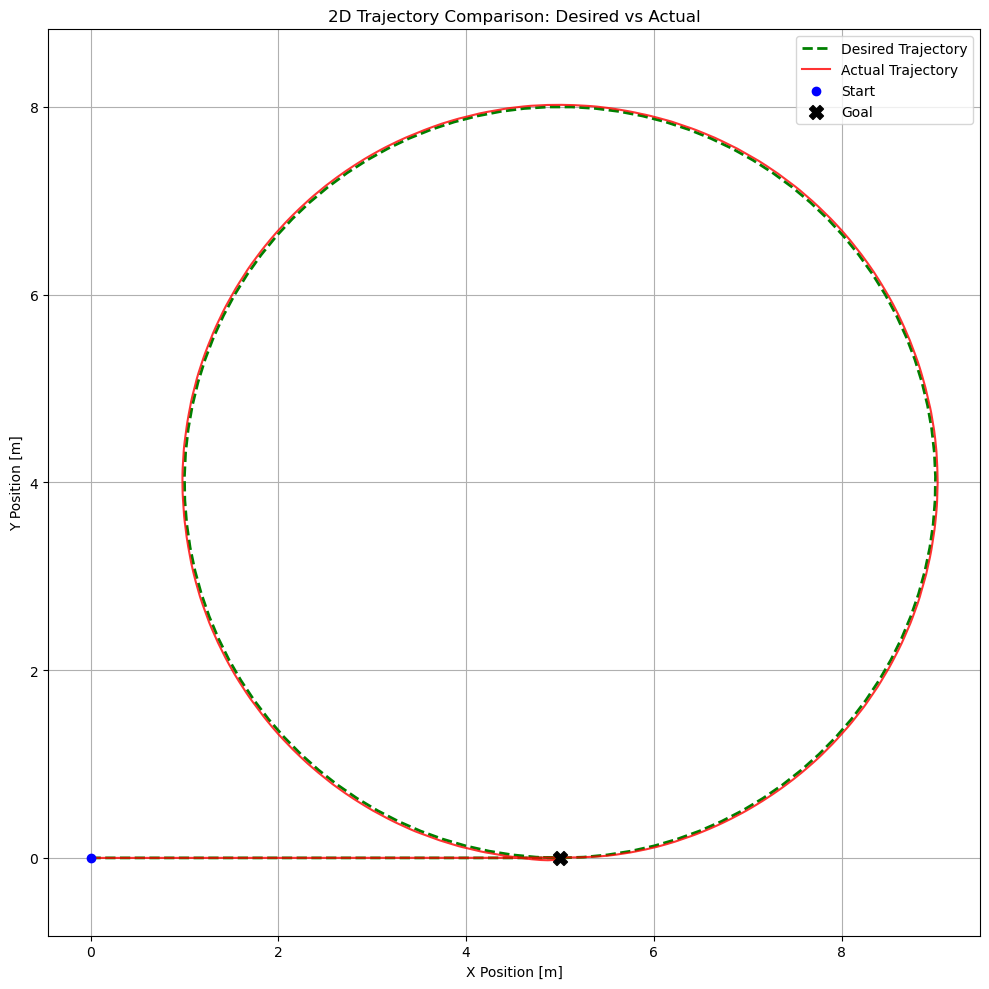

In [15]:
# 2D 궤적 비교 플롯
plt.figure(figsize=(10, 10))

# 목표 궤적 (녹색 점선)
plt.plot(desired_position_arr[:, 0], desired_position_arr[:, 1], 
         'g--', linewidth=2, label='Desired Trajectory')

# 실제 로봇 궤적 (빨간색 실선)
plt.plot(actual_position_arr[:, 0], actual_position_arr[:, 1], 
         'r-', linewidth=1.5, alpha=0.8, label='Actual Trajectory')

# 시작점과 끝점 표시 (선택 사항)
plt.scatter(desired_position_arr[0, 0], desired_position_arr[0, 1], color='blue', label='Start', zorder=5)
plt.scatter(desired_position_arr[-1, 0], desired_position_arr[-1, 1], color='black', marker='X', s=100, label='Goal', zorder=5)

plt.xlabel('X Position [m]')
plt.ylabel('Y Position [m]')
plt.title('2D Trajectory Comparison: Desired vs Actual')
plt.legend()
plt.grid(True)

plt.axis('equal')

plt.tight_layout()
plt.savefig('trajectory_2d_comparison.png')
plt.show()